# 🌌 CMB Foreground Separation Workshop
## Monte Carlo / Bayesian Approach
<u>solutions</u>

---

The following notebook holds the solutions, as well as the full working code for the UBC astronomy club coding workshop 3

created by Wrik Steven Sen

**Workshop Duration:** 50-60 minutes

**Before you proceed, save a copy in your drive. DO NOT edit this notebook.**

---

## Objective

In this workshop, you will learn how to extract the Cosmic Microwave Background (CMB) signal from foreground contamination using **Monte Carlo (MCMC) methods**.

By the end of this session, you will:
- Understand the parametric approach to component separation
- Implement a Metropolis-Hastings MCMC sampler
- Extract CMB with uncertainty estimates
- Fit foreground spectral parameters from the data

| Section | Topic | Time |
|---------|-------|------|
| Setup | Environment and data loading | 5 min |
| Part 1 | The Parametric Model | 10 min |
| Part 2 | MCMC Sampling | 25 min |
| Part 3 | Results and Uncertainty | 15 min |
| Wrap-up | Summary and Comparison to ILC | 5 min |

---
## Background: Bayesian Component Separation

The **Monte Carlo / Bayesian approach** differs from ILC:
1. We write down an explicit model for how foregrounds emit at each frequency
2. We use MCMC to sample from the posterior distribution of model parameters
3. We get both estimates AND uncertainties!

This is the approach used by **Planck's Commander** pipeline.

### The Data Model

$$d(\nu) = s_{\text{CMB}} + s_{\text{sync}} \cdot \left(\frac{\nu}{\nu_{\text{ref}}}\right)^{\beta_s} + s_{\text{dust}} \cdot f_{\text{dust}}(\nu) + n(\nu)$$

In [ ]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

np.random.seed(42) # the meaning of life

In [ ]:
# Constants

# Planck's constant: relates the energy of a photon to its frequency
# E = h × frequency
h_planck = 6.62607015e-34  # Units: Joule × seconds

# Boltzmann's constant: relates temperature to energy
# It tells us how much energy corresponds to a given temperature
k_boltzmann = 1.380649e-23  # Units: Joules per Kelvin

# Speed of light: the fastest anything can travel
c_light = 2.99792458e8  # Units: meters per second (about 300,000 km/s!)

# =============================================================================
# OBSERVATION FREQUENCIES
# These match the Planck satellite's frequency channels
# =============================================================================

# Our observation frequencies in GigaHertz (GHz)
# np.array() creates a NumPy array - like a list but optimized for math
FREQUENCIES_GHZ = np.array([30, 44, 70, 100, 143, 217, 353])

# Convert to Hertz (Hz) for physics calculations
# 1 GHz = 1 billion Hz = 10^9 Hz
FREQUENCIES_HZ = FREQUENCIES_GHZ * 1e9

# Reference frequencies: we define component amplitudes at these frequencies
# Synchrotron amplitude is defined at 30 GHz (where it's brightest)
NU_REF_SYNC = 30e9  # 30 GHz in Hz

# Dust amplitude is defined at 353 GHz (where it's brightest)
NU_REF_DUST = 353e9  # 353 GHz in Hz

# Dust temperature: typical temperature of dust grains in our galaxy
# 20 K is about -253°C — very cold by human standards,
# but much warmer than the CMB (2.7 K) or deep space!
T_DUST = 20.0  # Kelvin

In [ ]:
# =============================================================================
# OBSERVATION FREQUENCIES
# These match the Planck satellite's frequency channels
# =============================================================================

# Our observation frequencies in GigaHertz (GHz)
# np.array() creates a NumPy array - like a list but optimized for math
FREQUENCIES_GHZ = np.array([30, 44, 70, 100, 143, 217, 353])

# Convert to Hertz (Hz) for physics calculations
# 1 GHz = 1 billion Hz = 10^9 Hz
FREQUENCIES_HZ = FREQUENCIES_GHZ * 1e9

# Reference frequencies: we define component amplitudes at these frequencies
# Synchrotron amplitude is defined at 30 GHz (where it's brightest)
NU_REF_SYNC = 30e9  # 30 GHz in Hz

# Dust amplitude is defined at 353 GHz (where it's brightest)
NU_REF_DUST = 353e9  # 353 GHz in Hz

# Dust temperature: typical temperature of dust grains in our galaxy
# 20 K is about -253°C — very cold by human standards,
# but much warmer than the CMB (2.7 K) or deep space!
T_DUST = 20.0  # Kelvin

In [ ]:
print(f"Observing at {len(FREQUENCIES_GHZ)} frequency channels:")
print(f"  {FREQUENCIES_GHZ} GHz")
print(f"\nReference frequencies:")
print(f"  Synchrotron defined at: {NU_REF_SYNC/1e9:.0f} GHz")
print(f"  Dust defined at:        {NU_REF_DUST/1e9:.0f} GHz")
print(f"  Dust temperature:       {T_DUST} K")

print("✓ Setup complete")

Observing at 7 frequency channels:
  [ 30  44  70 100 143 217 353] GHz

Reference frequencies:
  Synchrotron defined at: 30 GHz
  Dust defined at:        353 GHz
  Dust temperature:       20.0 K
✓ Setup complete


In [ ]:
# =============================================================================
# SPECTRAL SCALING FUNCTIONS
# These functions calculate how bright each component is at different frequencies
# =============================================================================

def planck_function(nu, T):
    """
    The Planck blackbody function.

    This describes how hot objects emit light. Think of heating metal:
    - Cool metal doesn't glow
    - Warm metal glows red
    - Hot metal glows orange, then yellow, then white

    This function tells us exactly how much light comes out at each
    frequency for a given temperature.

    INPUTS:
        nu : frequency in Hz (can be a single number or an array)
        T  : temperature in Kelvin

    OUTPUT:
        The brightness (spectral radiance) at that frequency
    """
    # This is the standard Planck formula from thermal physics
    # x is a dimensionless ratio that appears in the formula
    x = h_planck * nu / (k_boltzmann * T)

    # The Planck function formula
    return (2 * h_planck * nu**3 / c_light**2) / (np.exp(x) - 1)


def synchrotron_spectrum(nu, beta_s=-3.0):
    """
    Calculate how synchrotron brightness scales with frequency.

    This is a "power law" — the brightness is proportional to
    frequency raised to some power (the spectral index beta_s).

    Since beta_s is negative (typically -3), higher frequencies
    give smaller values, meaning synchrotron gets DIMMER at
    higher frequencies.

    INPUTS:
        nu     : frequency in Hz (can be array)
        beta_s : spectral index (default -3.0)

    OUTPUT:
        Scaling factor relative to 30 GHz
        (Returns 1.0 at 30 GHz, smaller at higher frequencies)
    """
    # Calculate the frequency ratio and raise to power beta_s
    # nu / NU_REF_SYNC = frequency / 30 GHz
    return (nu / NU_REF_SYNC) ** beta_s


def dust_spectrum(nu):
    """
    Calculate how thermal dust brightness scales with frequency.

    Dust emission is a "modified blackbody" — it's like the Planck
    function but modified by the dust grain properties.

    Unlike synchrotron, dust gets BRIGHTER at higher frequencies
    (in the frequency range we're working with).

    INPUTS:
        nu : frequency in Hz (can be array)

    OUTPUT:
        Scaling factor relative to 353 GHz
        (Returns 1.0 at 353 GHz, smaller at lower frequencies)
    """
    # The dust spectral index (positive = gets brighter at higher freq)
    beta_d = 1.5

    # Combine the power law with the blackbody ratio
    frequency_term = (nu / NU_REF_DUST) ** beta_d
    blackbody_ratio = planck_function(nu, T_DUST) / planck_function(NU_REF_DUST, T_DUST)

    return frequency_term * blackbody_ratio


print("✓ Spectral functions defined!")
print("\nLet's test them at different frequencies:\n")

print("SYNCHROTRON (should get smaller at higher frequencies):")
print(f"  At  30 GHz: {synchrotron_spectrum(30e9):.4f} (reference = 1.0)")
print(f"  At 100 GHz: {synchrotron_spectrum(100e9):.4f} (much dimmer!)")
print(f"  At 353 GHz: {synchrotron_spectrum(353e9):.6f} (almost zero!)")

print("\nDUST (should get smaller at lower frequencies):")
print(f"  At 353 GHz: {dust_spectrum(353e9):.4f} (reference = 1.0)")
print(f"  At 100 GHz: {dust_spectrum(100e9):.4f} (much dimmer!)")
print(f"  At  30 GHz: {dust_spectrum(30e9):.6f} (almost zero!)")

✓ Spectral functions defined!

Let's test them at different frequencies:

SYNCHROTRON (should get smaller at higher frequencies):
  At  30 GHz: 1.0000 (reference = 1.0)
  At 100 GHz: 0.0270 (much dimmer!)
  At 353 GHz: 0.000614 (almost zero!)

DUST (should get smaller at lower frequencies):
  At 353 GHz: 1.0000 (reference = 1.0)
  At 100 GHz: 0.0168 (much dimmer!)
  At  30 GHz: 0.000272 (almost zero!)


In [ ]:
def generate_gaussian_field(npix, power_amplitude=1000, power_slope=-2.5):
    """
    Generate a random 2D map with realistic spatial structure.

    Real sky maps aren't just random noise at each pixel — they have
    structure on different scales (big blobs and small blobs). This
    function creates maps that look like real sky emission.

    HOW IT WORKS (simplified):
    1. We work in "Fourier space" where we control how much power
       (fluctuation strength) exists at each spatial scale
    2. Large scales (big blobs) get more power than small scales
    3. We transform back to real space to get our map

    You don't need to understand the details — just know that this
    creates realistic-looking sky maps!

    INPUTS:
        npix : Number of pixels per side (we make npix × npix maps)
        power_amplitude : Overall strength of fluctuations
        power_slope : How power drops off with scale (more negative = smoother)

    OUTPUT:
        A 2D numpy array of shape (npix, npix)
    """
    # Create a grid of spatial frequencies
    freqs = np.fft.fftfreq(npix)
    fx, fy = np.meshgrid(freqs, freqs)
    k = np.sqrt(fx**2 + fy**2)  # Distance from center in frequency space

    # Create power spectrum (how much fluctuation at each scale)
    with np.errstate(divide='ignore', invalid='ignore'):
        power = power_amplitude * (k * npix / 10) ** power_slope
        power = np.where(np.isfinite(power) & (k > 0), power, 0)

    # Random phases make each map unique
    phases = np.random.uniform(0, 2*np.pi, (npix, npix))

    # Combine and transform to real space
    fourier = np.sqrt(power / 2) * np.exp(1j * phases)
    return np.real(np.fft.ifft2(fourier)) * npix

In [ ]:
def generate_sky_maps(npix=128, noise_level=30.0, cmb_amp=110.0,
                      sync_amp=70.0, dust_amp=50.0, beta_s=-3.0):
    """
    Generate complete simulated multi-frequency sky observations.

    This function creates fake data that mimics what a real telescope
    would see when observing the microwave sky.

    INPUTS:
        npix        : Size of maps (npix × npix pixels)
        noise_level : Random noise level per channel [μK]
        cmb_amp     : RMS amplitude of CMB fluctuations [μK]
        sync_amp    : Synchrotron amplitude at 30 GHz [μK]
        dust_amp    : Dust amplitude at 353 GHz [μK]
        beta_s      : Synchrotron spectral index

    OUTPUT:
        Dictionary containing all maps and parameters
    """
    print("="*60)
    print("GENERATING SIMULATED SKY DATA")
    print("="*60)
    print(f"Map size: {npix} × {npix} = {npix**2:,} pixels")
    print(f"Frequency channels: {len(FREQUENCIES_GHZ)}")
    print()

    # =========================================================================
    # STEP 1: Create the CMB map
    # =========================================================================
    print("Step 1: Generating CMB temperature fluctuations...")
    # The CMB has a specific pattern of fluctuations
    cmb = generate_gaussian_field(npix, 6000, -0.5)
    # Normalize to desired RMS amplitude
    # np.std() calculates the standard deviation (RMS)
    cmb = cmb / np.std(cmb) * cmb_amp
    print(f"   CMB RMS amplitude: {np.std(cmb):.1f} μK")

    # =========================================================================
    # STEP 2: Create the synchrotron map
    # =========================================================================
    print("Step 2: Generating synchrotron emission template...")
    # Synchrotron has its own spatial pattern (different from CMB)
    # np.abs() makes it positive (emission is always positive)
    sync = np.abs(generate_gaussian_field(npix, 2000, -2.8))
    sync = sync / np.std(sync) * sync_amp
    print(f"   Synchrotron RMS at 30 GHz: {np.std(sync):.1f} μK")

    # =========================================================================
    # STEP 3: Create the dust map
    # =========================================================================
    print("Step 3: Generating thermal dust template...")
    # Dust has yet another spatial pattern
    dust = np.abs(generate_gaussian_field(npix, 1500, -2.5))
    dust = dust / np.std(dust) * dust_amp
    print(f"   Dust RMS at 353 GHz: {np.std(dust):.1f} μK")

    # =========================================================================
    # STEP 4: Combine components at each frequency
    # =========================================================================
    print("Step 4: Combining components at each frequency...")

    # Create array to hold all frequency maps
    # Shape: (number_of_frequencies, npix, npix)
    n_freq = len(FREQUENCIES_HZ)
    observed = np.zeros((n_freq, npix, npix))

    # Loop over each frequency
    for i, (nu_hz, nu_ghz) in enumerate(zip(FREQUENCIES_HZ, FREQUENCIES_GHZ)):
        # At each frequency, we observe:
        # CMB (constant) + synchrotron (scaled) + dust (scaled) + noise

        cmb_contribution = cmb  # CMB is the same at all frequencies!
        sync_contribution = sync * synchrotron_spectrum(nu_hz, beta_s)
        dust_contribution = dust * dust_spectrum(nu_hz)
        # Artificially add noise to make simulation closer to reality
        noise = np.random.normal(0, noise_level, (npix, npix))

        observed[i] = cmb_contribution + sync_contribution + dust_contribution + noise

    print(f"   ✓ Generated {n_freq} frequency maps")
    print()
    print("="*60)
    print("SIMULATION COMPLETE!")
    print("="*60)

    # Return everything in a dictionary
    # A dictionary lets us store multiple things with descriptive names
    return {
        'observed_maps': observed,      # What the telescope sees (7 maps)
        'cmb_input': cmb,               # The TRUE CMB (our target!)
        'sync_input': sync,             # True synchrotron template
        'dust_input': dust,             # True dust template
        'frequencies_hz': FREQUENCIES_HZ,
        'frequencies_ghz': FREQUENCIES_GHZ,
        'npix': npix,
        'noise_std': noise_level,
        'beta_s_true': beta_s           # True spectral index (we'll try to recover this!)
    }

In [ ]:
# Generate the simulated sky data
# This creates our "fake" observations that we'll analyze
data = generate_sky_maps()

GENERATING SIMULATED SKY DATA
Map size: 128 × 128 = 16,384 pixels
Frequency channels: 7

Step 1: Generating CMB temperature fluctuations...
   CMB RMS amplitude: 110.0 μK
Step 2: Generating synchrotron emission template...
   Synchrotron RMS at 30 GHz: 70.0 μK
Step 3: Generating thermal dust template...
   Dust RMS at 353 GHz: 50.0 μK
Step 4: Combining components at each frequency...
   ✓ Generated 7 frequency maps

SIMULATION COMPLETE!


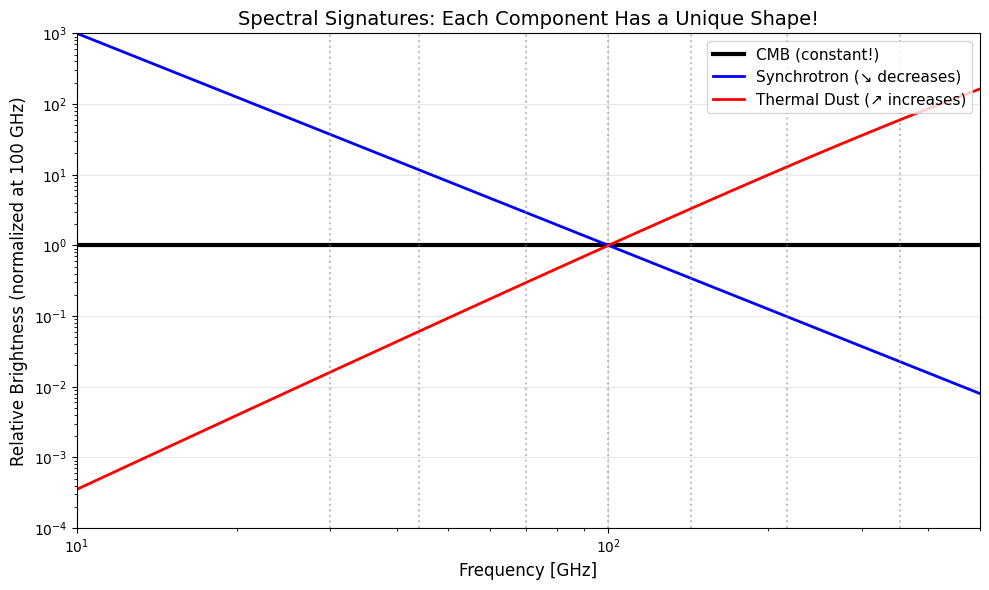


📊 KEY INSIGHT:
   The different slopes are what let us separate the components!
   By observing at multiple frequencies, we can figure out
   how much of each component is present.


In [ ]:
# Create an array of frequencies for plotting (from 10 to 500 GHz)
# np.logspace creates logarithmically-spaced points (good for log-scale plots)
freq_for_plot = np.logspace(np.log10(10), np.log10(500), 100)  # 100 points
freq_hz = freq_for_plot * 1e9  # Convert to Hz

# Calculate scaling for each component
# We normalize at 100 GHz so all three lines cross at the same point
cmb_scaling = np.ones_like(freq_for_plot)  # CMB is constant = 1 everywhere
sync_scaling = synchrotron_spectrum(freq_hz) / synchrotron_spectrum(100e9)
dust_scaling = dust_spectrum(freq_hz) / dust_spectrum(100e9)

# Create the plot
# plt.figure() creates a new figure with specified size (width, height) in inches
plt.figure(figsize=(10, 6))

# plt.loglog() makes both axes logarithmic (powers of 10)
# This is good for seeing power laws as straight lines
plt.loglog(freq_for_plot, cmb_scaling, 'k-', lw=3, label='CMB (constant!)')
plt.loglog(freq_for_plot, sync_scaling, 'b-', lw=2, label='Synchrotron (↘ decreases)')
plt.loglog(freq_for_plot, dust_scaling, 'r-', lw=2, label='Thermal Dust (↗ increases)')

# Mark our observation frequencies with vertical dashed lines
for f in FREQUENCIES_GHZ:
    plt.axvline(f, color='gray', ls=':', alpha=0.5)

# Labels and formatting
plt.xlabel('Frequency [GHz]', fontsize=12)
plt.ylabel('Relative Brightness (normalized at 100 GHz)', fontsize=12)
plt.title('Spectral Signatures: Each Component Has a Unique Shape!', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.xlim(10, 500)
plt.ylim(1e-4, 1e3)
plt.grid(True, alpha=0.3)
plt.tight_layout()  # Adjusts spacing so nothing overlaps
plt.show()

print("\n📊 KEY INSIGHT:")
print("   The different slopes are what let us separate the components!")
print("   By observing at multiple frequencies, we can figure out")
print("   how much of each component is present.")

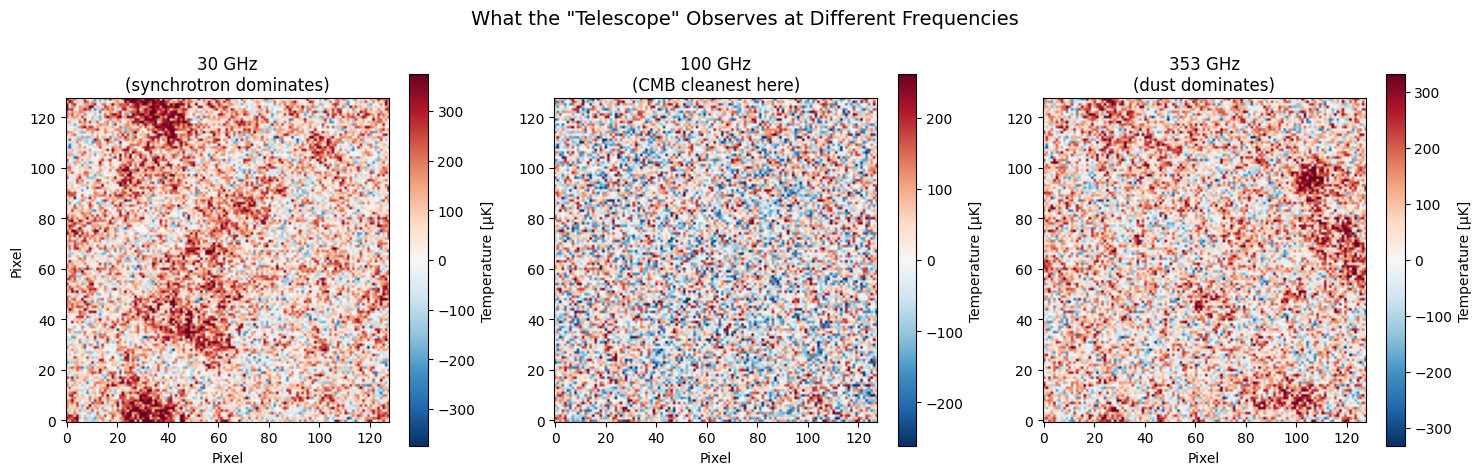


📊 WHAT TO NOTICE:
   • The three maps look DIFFERENT from each other!
   • 30 GHz has extra structure from bright synchrotron emission
   • 353 GHz has different extra structure from bright dust emission
   • 100 GHz is cleanest, but still not pure CMB


In [ ]:
# Create a figure with 3 subplots side by side
# figsize=(15, 4.5) means 15 inches wide, 4.5 inches tall
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Which frequencies to show:
# Index 0 = first frequency (30 GHz)
# Index 3 = fourth frequency (100 GHz)
# Index -1 = last frequency (353 GHz)
indices = [0, 3, -1]
titles = ['30 GHz\n(synchrotron dominates)',
          '100 GHz\n(CMB cleanest here)',
          '353 GHz\n(dust dominates)']

# Loop over the three panels
for ax, idx, title in zip(axes, indices, titles):
    img = data['observed_maps'][idx]  # Get the map at this frequency

    # Set color scale limits using the 98th percentile
    # This avoids extreme values dominating the color scale
    vmax = np.percentile(np.abs(img), 98)

    # Display the image
    # cmap='RdBu_r': Red-White-Blue colormap (red=hot, blue=cold)
    # origin='lower': Put (0,0) at bottom-left (standard for astronomy)
    im = ax.imshow(img, cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Pixel')
    plt.colorbar(im, ax=ax, label='Temperature [μK]')

axes[0].set_ylabel('Pixel')
plt.suptitle('What the "Telescope" Observes at Different Frequencies', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 WHAT TO NOTICE:")
print("   • The three maps look DIFFERENT from each other!")
print("   • 30 GHz has extra structure from bright synchrotron emission")
print("   • 353 GHz has different extra structure from bright dust emission")
print("   • 100 GHz is cleanest, but still not pure CMB")

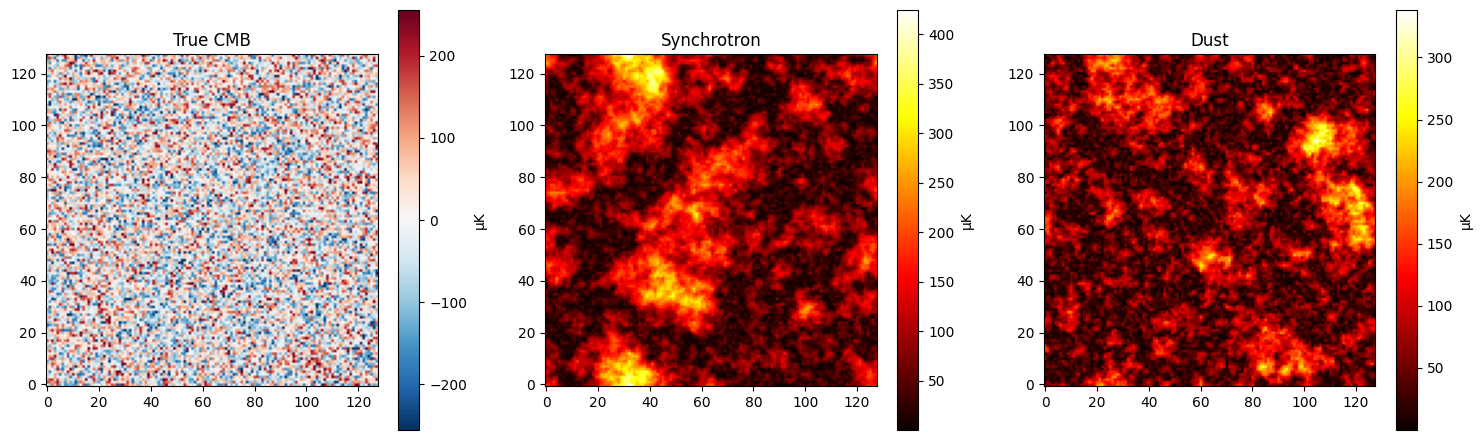

In [ ]:
# True components
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmax = np.percentile(np.abs(data['cmb_input']), 98)

im0 = axes[0].imshow(data['cmb_input'], cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
axes[0].set_title('True CMB')
plt.colorbar(im0, ax=axes[0], label='μK')

im1 = axes[1].imshow(data['sync_input'], cmap='hot', origin='lower')
axes[1].set_title('Synchrotron')
plt.colorbar(im1, ax=axes[1], label='μK')

im2 = axes[2].imshow(data['dust_input'], cmap='hot', origin='lower')
axes[2].set_title('Dust')
plt.colorbar(im2, ax=axes[2], label='μK')

plt.tight_layout()
plt.show()

---
## EXERCISE 1 SOLUTION: Forward Model

In [ ]:
# Extract pixel
# Choose the center pixel of our map
# // is integer division (e.g., 128 // 2 = 64)
cx, cy = data['npix'] // 2, data['npix'] // 2

# Get the observed data at this pixel
# data['observed_maps'] has shape (7, 128, 128)
# [:, cy, cx] means: all frequencies, at position (cy, cx)
# Result: array of 7 numbers (one per frequency)
pixel_observed = data['observed_maps'][:, cy, cx]

# Noise standard deviation at each frequency
# np.ones() creates an array of 1s, then we multiply by the noise level
pixel_noise_std = np.ones(len(FREQUENCIES_GHZ)) * data['noise_std']

# True values at this pixel (for checking our answer later!)
true_cmb = data['cmb_input'][cy, cx]
true_sync = data['sync_input'][cy, cx]
true_dust = data['dust_input'][cy, cx]

print(f"Selected center pixel: ({cx}, {cy})")
print()
print("TRUE VALUES at this pixel (our answer key):")
print(f"  CMB amplitude:         {true_cmb:8.2f} μK")
print(f"  Synchrotron amplitude: {true_sync:8.2f} μK (at 30 GHz)")
print(f"  Dust amplitude:        {true_dust:8.2f} μK (at 353 GHz)")
print(f"  Spectral index β_s:    {data['beta_s_true']:8.2f}")
print()
print(f"OBSERVED DATA at this pixel (7 frequencies):")
print(f"  Frequencies: {FREQUENCIES_GHZ} GHz")
print(f"  Values:      {np.round(pixel_observed, 1)} μK")

Selected center pixel: (64, 64)

TRUE VALUES at this pixel (our answer key):
  CMB amplitude:           -32.90 μK
  Synchrotron amplitude:    54.75 μK (at 30 GHz)
  Dust amplitude:            5.18 μK (at 353 GHz)
  Spectral index β_s:       -3.00

OBSERVED DATA at this pixel (7 frequencies):
  Frequencies: [ 30  44  70 100 143 217 353] GHz
  Values:      [ 40.8 -57.5 -37.6   8.5 -34.1 -75.4 -10.7] μK


In [ ]:
# ██████  SOLUTION  ██████

def forward_model(params, frequencies_hz):
    """
    Predict what we would observe given model parameters.

    This is called a "forward model" because it goes forward from
    parameters to predictions (the opposite of inference, which goes
    from data back to parameters).

    INPUTS:
        params : Dictionary containing:
                 's_cmb'  - CMB amplitude [μK]
                 's_sync' - Synchrotron amplitude at 30 GHz [μK]
                 's_dust' - Dust amplitude at 353 GHz [μK]
                 'beta_s' - Synchrotron spectral index

        frequencies_hz : Array of observation frequencies in Hz

    OUTPUT:
        Array of predicted observations at each frequency [μK]
    """
    # Extract parameters from the dictionary
    s_cmb = params['s_cmb']     # CMB amplitude
    s_sync = params['s_sync']   # Synchrotron amplitude at 30 GHz
    s_dust = params['s_dust']   # Dust amplitude at 353 GHz
    beta_s = params['beta_s']   # Synchrotron spectral index

    # Solution
    ############################################################################
    cmb = s_cmb * np.ones(len(frequencies_hz))
    sync = s_sync * synchrotron_spectrum(frequencies_hz, beta_s)
    dust = s_dust * dust_spectrum(frequencies_hz)
    model = cmb + sync + dust

    return model

### Notes
- Students often forget `np.ones()` for CMB
- Key insight: CMB being constant is why separation works

---
## EXERCISE 2 SOLUTION: Log-Likelihood

In [ ]:
# ██████  SOLUTION  ██████

def log_likelihood(params, observed, noise_std, frequencies_hz):
    """
    Calculate how well the model fits the data.

    Returns the log of the likelihood (we use log because actual
    likelihood values can be tiny numbers that cause computer errors).

    INPUTS:
        params         : Dictionary of model parameters
        observed       : Array of observed data at each frequency
        noise_std      : Array of noise standard deviations
        frequencies_hz : Array of frequencies in Hz

    OUTPUT:
        Log-likelihood value (higher = better fit, always ≤ 0)
    """
    # Get the model prediction using your forward model
    model = forward_model(params, frequencies_hz)

    # Solution
    ############################################################################
    residuals = observed - model
    chi_squared = np.sum((residuals / noise_std) ** 2)
    log_L = -0.5 * chi_squared

    return log_L

### Notes
- Common errors: sign mistakes, missing 0.5, wrong squaring
- Gaussian assumption simplifies things but isn't perfect for real data

---
## EXERCISE 3 SOLUTION: Log-Prior

In [ ]:
# ██████  SOLUTION  ██████

def log_prior(params):
    """
    Calculate the prior probability of the parameters.

    Returns -infinity if parameters are outside the allowed range
    (meaning these values are physically impossible, probability = 0).

    INPUTS:
        params : Dictionary of model parameters

    OUTPUT:
        Log of prior probability
    """
    s_cmb, s_sync, s_dust, beta_s = params['s_cmb'], params['s_sync'], params['s_dust'], params['beta_s']

    # Solution
    ############################################################################
    if not (-500 < s_cmb < 500): return -np.inf
    if not (0 < s_sync < 500): return -np.inf
    if not (0 < s_dust < 500): return -np.inf
    if not (-5 < beta_s < -1): return -np.inf
    log_p = -0.5 * ((beta_s - (-3.0)) / 0.5) ** 2

    return log_p

### Notes
- Priors encode physics (emission positive, β_s around -3)
- -np.inf means probability = 0

In [ ]:
# Log-posterior
def log_posterior(params, observed, noise_std, frequencies_hz):
    lp = log_prior(params)
    if not np.isfinite(lp): return -np.inf
    return lp + log_likelihood(params, observed, noise_std, frequencies_hz)

---
## EXERCISE 4 SOLUTION: MCMC Sampler

In [ ]:
# ██████  SOLUTION  ██████

def metropolis_hastings(initial_params, n_steps, proposal_std,
                        observed, noise_std, frequencies_hz):
    """
    Run the Metropolis-Hastings MCMC algorithm.

    INPUTS:
        initial_params : Starting parameter values (dictionary)
        n_steps        : Number of MCMC steps to take
        proposal_std   : How far to jump when proposing (dictionary)
        observed       : Observed data
        noise_std      : Noise standard deviation
        frequencies_hz : Observation frequencies

    OUTPUTS:
        chain           : Dictionary containing arrays of parameter values
        acceptance_rate : Fraction of proposals that were accepted
    """
    # The four parameters we're fitting
    param_names = ['s_cmb', 's_sync', 's_dust', 'beta_s']

    # Initialize storage for the "chain" of parameter values
    # Each parameter gets an array to store its value at each step
    chain = {name: np.zeros(n_steps) for name in param_names}

    # Start at the initial parameters
    # .copy() creates a copy so we don't modify the original
    current_params = initial_params.copy()
    current_log_post = log_posterior(current_params, observed, noise_std, frequencies_hz)

    # Count how many proposals we accept
    n_accepted = 0


    for i in tqdm(range(n_steps), desc="MCMC"):
      # Solution
      ############################################################################
        # Propose
        proposed_params = {name: current_params[name] + np.random.normal(0, proposal_std[name])
                          for name in param_names}
        proposed_log_post = log_posterior(proposed_params, observed, noise_std, frequencies_hz)

        # Accept/reject
        if np.log(np.random.random()) < proposed_log_post - current_log_post:
            current_params = proposed_params
            current_log_post = proposed_log_post
            n_accepted += 1

        # End Solution
        ############################################################################
        for name in param_names:
            chain[name][i] = current_params[name]

    # Calculate and report acceptance rate
    acceptance_rate = n_accepted / n_steps
    print(f"\n✓ MCMC complete!")
    print(f"  Acceptance rate: {acceptance_rate:.1%}")
    print(f"  (Ideal range: 20% - 50%)")

    return chain, n_accepted/n_steps

### Notes

**Most common errors:**
1. `proposed = current` creates reference, not copy → use `.copy()` or dict comprehension
2. Acceptance: must use log-space comparison to avoid underflow
3. Forgetting to update `current_log_post` when accepting

**Key insight:**
```python
# We want: accept if random() < P(new)/P(old)
# In log: accept if log(random()) < log(P(new)) - log(P(old))
```

In [ ]:
# =============================================================================
# RUN THE MCMC!
# =============================================================================

# Starting point (deliberately NOT the true values - let MCMC find them!)
initial_params = {
    's_cmb': 0.0,      # Start at 0, not the true value
    's_sync': 50.0,    # A reasonable guess
    's_dust': 50.0,    # A reasonable guess
    'beta_s': -2.8     # Close to -3 but not exact
}

# Proposal standard deviations (how far to jump each step)
# These are tuned to give ~30% acceptance rate
# Too small = slow exploration
# Too large = too many rejections
proposal_std = {
    's_cmb': 8.0,
    's_sync': 8.0,
    's_dust': 5.0,
    'beta_s': 0.15
}

# Number of MCMC steps
n_steps = 10000

print("="*60)
print("RUNNING MCMC")
print("="*60)
print(f"Starting point:")
print(f"  s_cmb = {initial_params['s_cmb']}, s_sync = {initial_params['s_sync']}")
print(f"  s_dust = {initial_params['s_dust']}, beta_s = {initial_params['beta_s']}")
print(f"Number of steps: {n_steps:,}")
print()

# Run MCMC!
chain, acceptance_rate = metropolis_hastings(
    initial_params, n_steps, proposal_std,
    pixel_observed, pixel_noise_std, FREQUENCIES_HZ
)

RUNNING MCMC
Starting point:
  s_cmb = 0.0, s_sync = 50.0
  s_dust = 50.0, beta_s = -2.8
Number of steps: 10,000



MCMC: 100%|██████████| 10000/10000 [00:01<00:00, 5916.37it/s]


✓ MCMC complete!
  Acceptance rate: 70.4%
  (Ideal range: 20% - 50%)


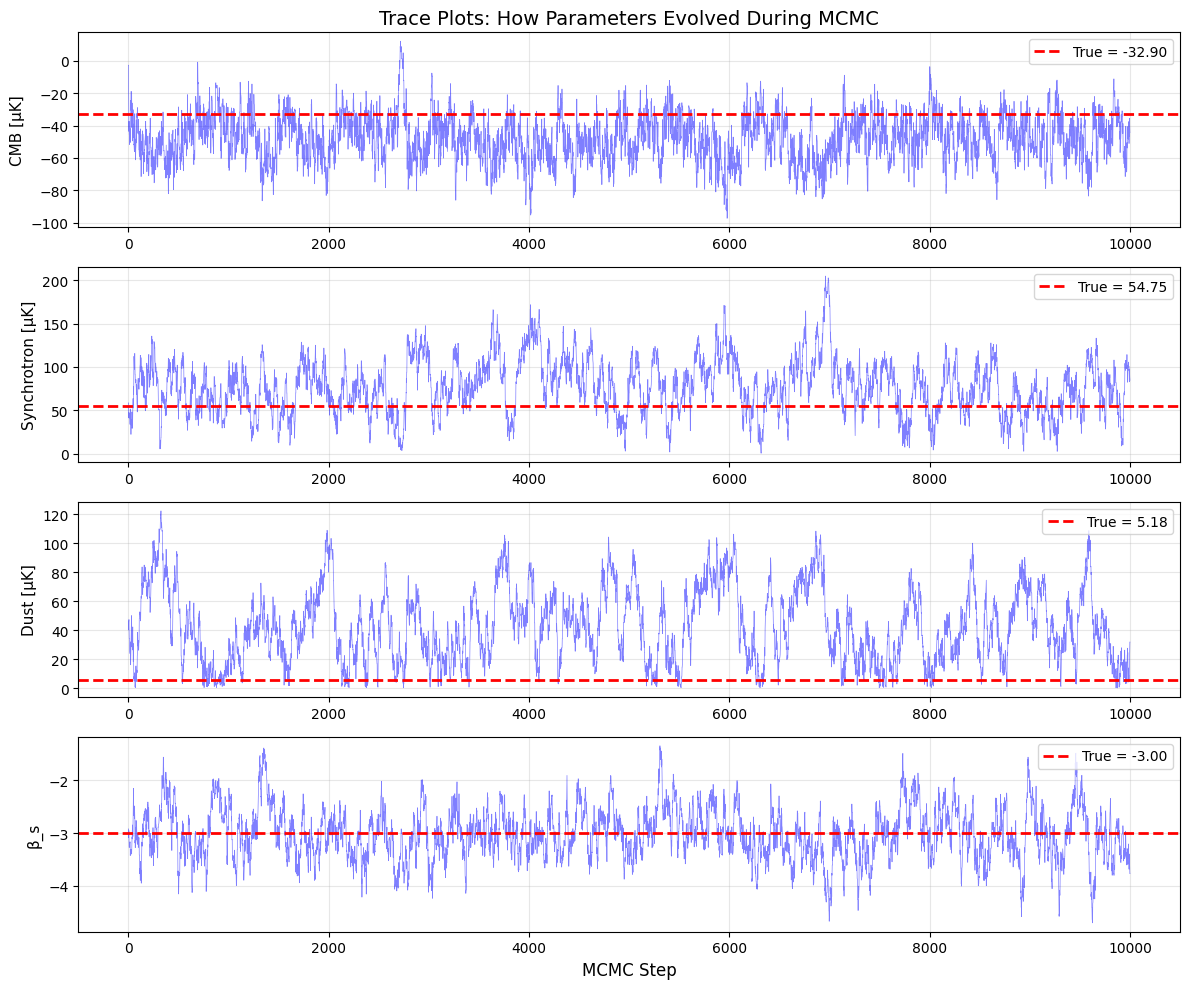


📊 WHAT TO LOOK FOR:
   • Each chain should fluctuate around the true value (red line)
   • The first ~1000 steps may show 'burn-in' (finding the right region)
   • Good mixing = lots of up-and-down movement (not stuck)


In [ ]:
# Trace plots
param_names = ['s_cmb', 's_sync', 's_dust', 'beta_s']
param_labels = ['CMB [μK]', 'Synchrotron [μK]', 'Dust [μK]', 'β_s']
true_values = [true_cmb, true_sync, true_dust, data['beta_s_true']]

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

for ax, name, label, true_val in zip(axes, param_names, param_labels, true_values):
    # Plot the chain (parameter value at each step)
    ax.plot(chain[name], 'b-', alpha=0.5, lw=0.5)

    # Mark the true value with a red dashed line
    ax.axhline(true_val, color='red', ls='--', lw=2, label=f'True = {true_val:.2f}')

    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('MCMC Step', fontsize=12)
axes[0].set_title('Trace Plots: How Parameters Evolved During MCMC', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📊 WHAT TO LOOK FOR:")
print("   • Each chain should fluctuate around the true value (red line)")
print("   • The first ~1000 steps may show 'burn-in' (finding the right region)")
print("   • Good mixing = lots of up-and-down movement (not stuck)")

In [ ]:
# Discard burn-in (first 2000 steps while chain was finding the right region)
burn_in = 2000

# Create new dictionary with only post-burn-in samples
samples = {}
for name in param_names:
    samples[name] = chain[name][burn_in:]  # [burn_in:] means "from burn_in to the end"

print(f"Discarding first {burn_in} samples as burn-in")
print(f"Using remaining {len(samples['s_cmb']):,} samples for analysis")

Discarding first 2000 samples as burn-in
Using remaining 8,000 samples for analysis


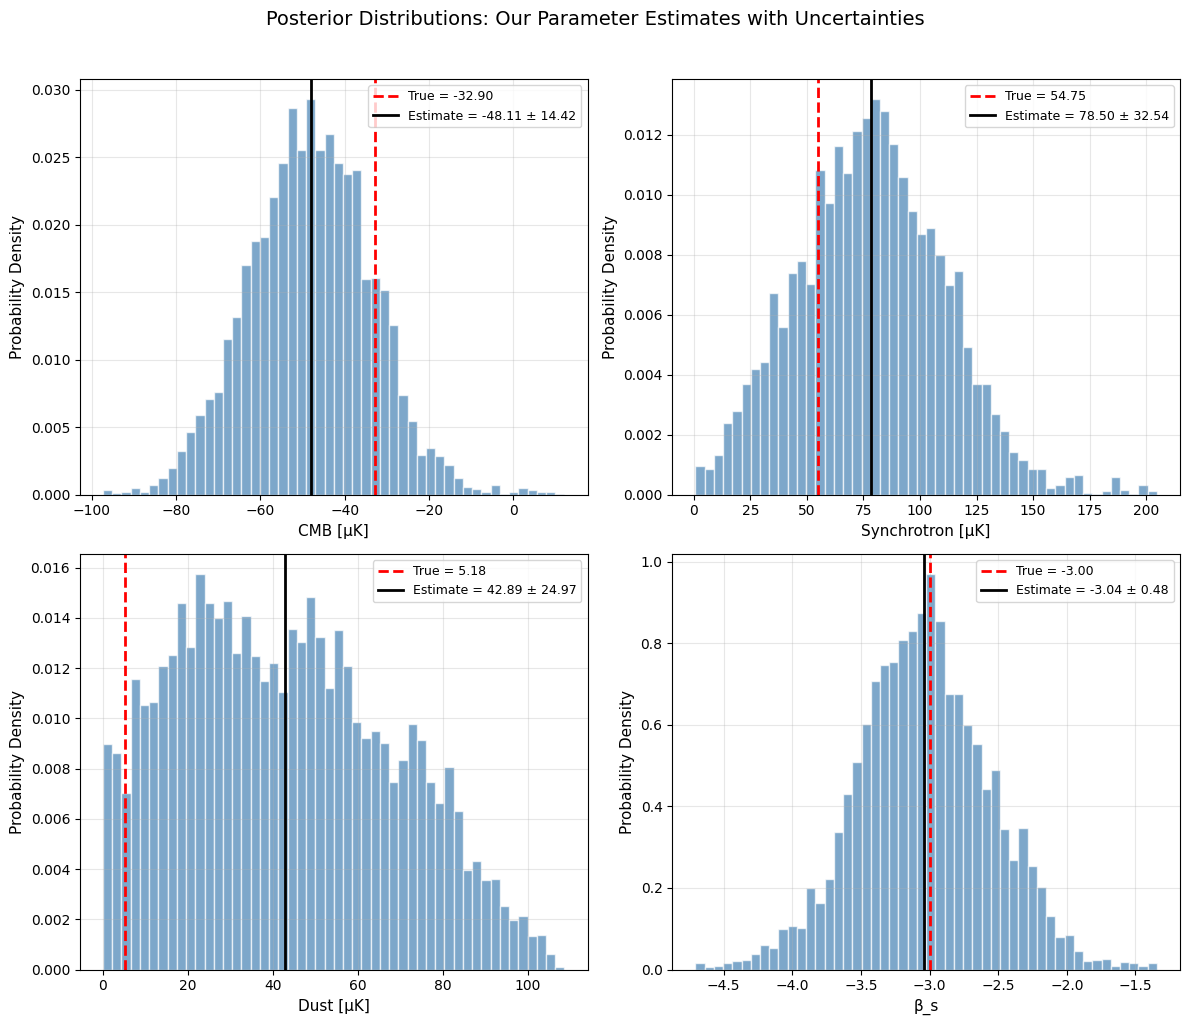

In [ ]:
# Plot posterior distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Convert 2×2 array to flat list for easy iteration

for ax, name, label, true_val in zip(axes, param_names, param_labels, true_values):
    # Histogram of samples = posterior distribution
    # density=True normalizes it to be a probability density
    ax.hist(samples[name], bins=50, density=True, alpha=0.7,
            color='steelblue', edgecolor='white')

    # Mark the true value
    ax.axvline(true_val, color='red', ls='--', lw=2, label=f'True = {true_val:.2f}')

    # Mark the posterior mean and standard deviation
    mean = np.mean(samples[name])
    std = np.std(samples[name])
    ax.axvline(mean, color='black', lw=2, label=f'Estimate = {mean:.2f} ± {std:.2f}')

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Probability Density', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Posterior Distributions: Our Parameter Estimates with Uncertainties', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Print a summary table of results
print("="*70)
print("MCMC RESULTS SUMMARY")
print("="*70)
print(f"{'Parameter':<20} {'True Value':>12} {'Estimate':>20} {'Error':>10}")
print("-"*70)

nice_names = ['CMB amplitude', 'Sync amplitude', 'Dust amplitude', 'Spectral index']

for name, nice_name, true_val in zip(param_names, nice_names, true_values):
    mean = np.mean(samples[name])
    std = np.std(samples[name])
    error = mean - true_val

    print(f"{nice_name:<20} {true_val:>12.2f} {mean:>10.2f} ± {std:<7.2f} {error:>+10.2f}")

print("="*70)
print("\n✓ The estimates are close to the true values!")
print("✓ The '±' values are uncertainties from MCMC — we get error bars for free!")

MCMC RESULTS SUMMARY
Parameter              True Value             Estimate      Error
----------------------------------------------------------------------
CMB amplitude              -32.90     -48.11 ± 14.42       -15.20
Sync amplitude              54.75      78.50 ± 32.54       +23.75
Dust amplitude               5.18      42.89 ± 24.97       +37.70
Spectral index              -3.00      -3.04 ± 0.48         -0.04

✓ The estimates are close to the true values!
✓ The '±' values are uncertainties from MCMC — we get error bars for free!


In [ ]:
# Full map reconstruction
def reconstruct_cmb_map(observed_maps, beta_s_est, frequencies_hz):
    """
    Reconstruct the CMB map using the spectral index from MCMC.

    For each pixel, we solve: data = A @ amplitudes
    where A is the mixing matrix and amplitudes = [s_cmb, s_sync, s_dust]

    Parameters:
        observed_maps: Array of shape (n_freq, ny, nx)
        beta_s_estimate: Spectral index from MCMC
        frequencies_hz: Observation frequencies

    Returns:
        cmb_map: Recovered CMB map
    """
    n_freq, ny, nx = observed_maps.shape
    A = np.column_stack([np.ones(n_freq), synchrotron_spectrum(frequencies_hz, beta_s_est), dust_spectrum(frequencies_hz)])
    cmb_map = np.zeros((ny, nx))
    for j in range(ny):
        for i in range(nx):
            amps, _, _, _ = np.linalg.lstsq(A, observed_maps[:, j, i], rcond=None)
            cmb_map[j, i] = amps[0]
    return cmb_map

beta_s_est = np.mean(samples['beta_s'])
print(f"Using β_s = {beta_s_est:.3f}")
cmb_recovered = reconstruct_cmb_map(data['observed_maps'], beta_s_est, FREQUENCIES_HZ)

Using β_s = -3.040


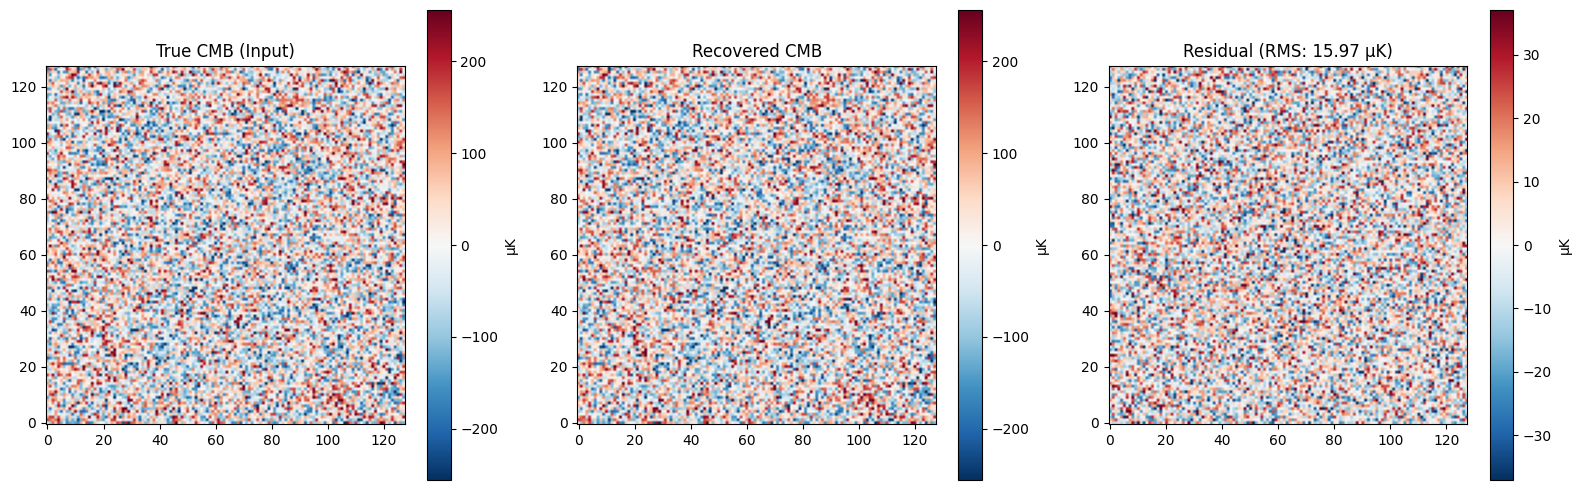

In [ ]:
# Compare maps: True vs Recovered vs Residual
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmb_true = data['cmb_input']
residual = cmb_recovered - cmb_true
vmax = np.percentile(np.abs(cmb_true), 98)
vmax_res = np.percentile(np.abs(residual), 98)

im0 = axes[0].imshow(cmb_true, cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
axes[0].set_title('True CMB (Input)')
plt.colorbar(im0, ax=axes[0], label='μK')

im1 = axes[1].imshow(cmb_recovered, cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
axes[1].set_title('Recovered CMB')
plt.colorbar(im1, ax=axes[1], label='μK')

im2 = axes[2].imshow(residual, cmap='RdBu_r', origin='lower', vmin=-vmax_res, vmax=vmax_res)
axes[2].set_title(f'Residual (RMS: {np.std(residual):.2f} μK)')
plt.colorbar(im2, ax=axes[2], label='μK')

plt.tight_layout()
plt.show()

In [ ]:
# Validation metrics
corr = np.corrcoef(cmb_true.flatten(), cmb_recovered.flatten())[0, 1]
var_exp = 1 - np.var(residual) / np.var(cmb_true)

print("="*50)
print("CMB RECOVERY RESULTS")
print("="*50)
print(f"Input CMB RMS:      {np.std(cmb_true):.2f} μK")
print(f"Recovered CMB RMS:  {np.std(cmb_recovered):.2f} μK")
print(f"Residual RMS:       {np.std(residual):.2f} μK")
print(f"Correlation:        {corr:.4f}")
print(f"Variance explained: {var_exp*100:.2f}%")
print("="*50)

CMB RECOVERY RESULTS
Input CMB RMS:      110.00 μK
Recovered CMB RMS:  110.97 μK
Residual RMS:       15.97 μK
Correlation:        0.9896
Variance explained: 97.89%


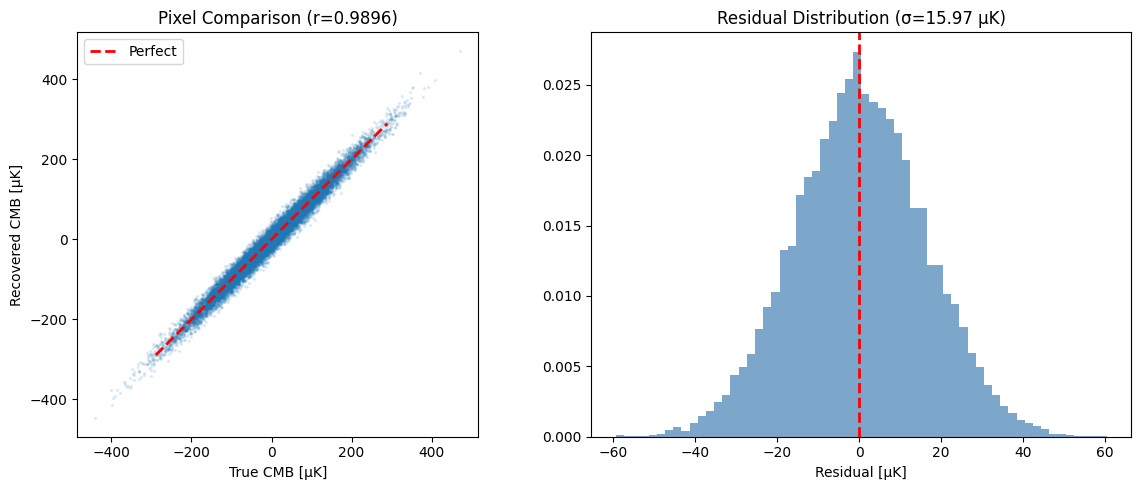

In [ ]:
# Scatter plot and residual histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(cmb_true.flatten(), cmb_recovered.flatten(), alpha=0.1, s=2)
lims = [-np.percentile(np.abs(cmb_true), 99), np.percentile(np.abs(cmb_true), 99)]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('True CMB [μK]')
axes[0].set_ylabel('Recovered CMB [μK]')
axes[0].set_title(f'Pixel Comparison (r={corr:.4f})')
axes[0].set_aspect('equal')
axes[0].legend()

axes[1].hist(residual.flatten(), bins=60, density=True, alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', ls='--', lw=2)
axes[1].set_xlabel('Residual [μK]')
axes[1].set_title(f'Residual Distribution (σ={np.std(residual):.2f} μK)')

plt.tight_layout()
plt.show()